# FIM軌跡 インタラクティブダッシュボード

## 概要
FIM（Functional Independence Measure）の縦断軌跡データを読み込み、潜在クラス分析を行うインタラクティブダッシュボードです。

### 機能
1. **データ読み込み** - CSVファイルからデータをロード
2. **全員FIM軌跡表示** - 全患者のFIM軌跡を可視化
3. **インタラクティブダッシュボード**:
   - 0週FIMスコアがない症例の除外チェックボックス
   - 0週FIMスコアの下限・上限フィルタ
   - Week since admission の範囲（上限）フィルタ
   - 情報量基準（BIC）による最適クラスタ数の自動決定
   - Individual Trajectories (sampled) + Class Means 描画
   - クラスタ別 Table 1 描画

### 高速化
- R/rpy2の代わりにscikit-learnのGaussianMixtureを使用（数分→数十ミリ秒）
- 患者ごとの軌跡特徴量（切片・傾き）を事前抽出し、GMM でクラスタリング
- BIC による最適クラスタ数選択（sklearn内蔵）
- debounce付きウィジェットで過度な再計算を防止

### 必要パッケージ
```
pip install numpy pandas matplotlib scikit-learn scipy ipywidgets tableone ipympl jupyterlab
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy import stats
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from tableone import TableOne
import warnings
import time
import os

warnings.filterwarnings('ignore')

# --- matplotlib backend ---
# ipympl (%matplotlib widget) が使えればインタラクティブ、
# なければ inline にフォールバック
try:
    get_ipython().run_line_magic('matplotlib', 'widget')
    print('Backend: ipympl (interactive)')
except Exception:
    try:
        get_ipython().run_line_magic('matplotlib', 'inline')
        print('Backend: inline (static)')
    except Exception:
        pass

print('Setup complete.')


Backend: ipympl (interactive)
Setup complete.


## 1. データ読み込み

下のセルの `DATA_PATH` を自分のCSVファイルのパスに変更してください。  
または `FileUpload` ウィジェットでアップロードすることもできます。


In [2]:
# ====================================================
# データ読み込み
# ====================================================
# 方法1: ファイルパスを直接指定（こちらを優先）
DATA_PATH = "/home/ubuntu/repos/wip/test_data.csv"  # 例: r"C:\\Users\\user\\Downloads\\moriyama_lcmm_rwd.csv"

# 方法2: ファイルアップロードウィジェット
uploader = widgets.FileUpload(accept='.csv', multiple=False, description='CSVアップロード')
load_btn = widgets.Button(description='ファイルパスから読み込み', button_style='primary')
status_label = widgets.HTML(value='<i>CSVファイルをアップロードするか、DATA_PATHを設定してload_btnを押してください</i>')

raw_data = None  # グローバル変数

def _load_from_path(path):
    global raw_data
    raw_data = pd.read_csv(path)
    status_label.value = f'<b style="color:green">読み込み完了: {len(raw_data)} 行, {raw_data.shape[1]} 列</b>'
    print(f"Columns: {list(raw_data.columns)}")
    print(f"Shape: {raw_data.shape}")
    display(raw_data.head())

def on_upload_change(change):
    global raw_data
    if uploader.value:
        import io
        uploaded = list(uploader.value.values())[0] if isinstance(uploader.value, dict) else uploader.value[0]
        content = uploaded['content'] if isinstance(uploaded, dict) else uploaded.content
        raw_data = pd.read_csv(io.BytesIO(content))
        status_label.value = f'<b style="color:green">アップロード読み込み完了: {len(raw_data)} 行, {raw_data.shape[1]} 列</b>'
        print(f"Columns: {list(raw_data.columns)}")
        print(f"Shape: {raw_data.shape}")
        display(raw_data.head())

def on_load_btn(b):
    if DATA_PATH and os.path.exists(DATA_PATH):
        _load_from_path(DATA_PATH)
    else:
        status_label.value = '<b style="color:red">DATA_PATHが未設定または存在しません</b>'

uploader.observe(on_upload_change, names='value')
load_btn.on_click(on_load_btn)

display(widgets.VBox([
    widgets.HBox([uploader, load_btn]),
    status_label
]))

# DATA_PATHが既に設定されていれば自動読み込み
if DATA_PATH and os.path.exists(DATA_PATH):
    _load_from_path(DATA_PATH)


Columns: ['id', 'delta_week', 'fim', 'yo', 'male', 'did_fall']
Shape: (553, 6)


,id,delta_week,fim,yo,male,did_fall
0,1,0,59.7,55,0,1
1,1,8,40.7,55,0,1
2,1,9,41.4,55,0,1
3,1,12,34.9,55,0,1
4,1,16,30.4,55,0,1


## 2. データ前処理

列名のリネーム、重複除外、3回以上観測のある患者のみ抽出を行います。


In [3]:
# ====================================================
# データ前処理
# ====================================================
assert raw_data is not None, "先にデータを読み込んでください"

data = raw_data.copy()

# --- 列名リネーム ---
rename_dict = {
    "id": "ID",
    "delta_week": "week",
    "fim": "FIM",
    "yo": "age",
    "male": "sex",
    "did_fall": "fall_any"
}
# 存在する列のみリネーム
rename_dict_valid = {k: v for k, v in rename_dict.items() if k in data.columns}
data = data.rename(columns=rename_dict_valid)

# --- 必須列の確認 ---
required_cols = ["ID", "week", "FIM"]
missing = [c for c in required_cols if c not in data.columns]
if missing:
    raise ValueError(f"必須列が見つかりません: {missing}. 現在の列: {list(data.columns)}")

# --- 型変換 ---
data["ID"] = data["ID"].astype(str)
data["week"] = pd.to_numeric(data["week"], errors="coerce")
data["FIM"] = pd.to_numeric(data["FIM"], errors="coerce")

# fall_any があれば数値化
if "fall_any" in data.columns:
    data["fall_any"] = pd.to_numeric(data["fall_any"], errors="coerce")

# --- 欠損除外 ---
data = data.dropna(subset=["ID", "week", "FIM"]).copy()

# --- (ID, week) 重複除外 ---
before = len(data)
data = data.drop_duplicates(subset=["ID", "week"], keep="first")
after = len(data)
print(f"(ID, week) 重複除外: {before} -> {after} 行 (削除: {before - after})")

# --- 3回以上観測のある患者のみ ---
id_counts = data["ID"].value_counts()
ids_ge3 = id_counts[id_counts >= 3].index
data = data[data["ID"].isin(ids_ge3)].copy()
data = data.sort_values(["ID", "week"]).reset_index(drop=True)

print(f"患者数 (>=3 observations): {data['ID'].nunique()}")
print(f"総観測数: {len(data)}")
print(f"Week 範囲: {data['week'].min()} - {data['week'].max()}")
print(f"FIM 範囲: {data['FIM'].min()} - {data['FIM'].max()}")


(ID, week) 重複除外: 553 -> 553 行 (削除: 0)
患者数 (>=3 observations): 100
総観測数: 553
Week 範囲: 0 - 26
FIM 範囲: 18.0 - 126.0


## 3. 全員FIM軌跡の表示


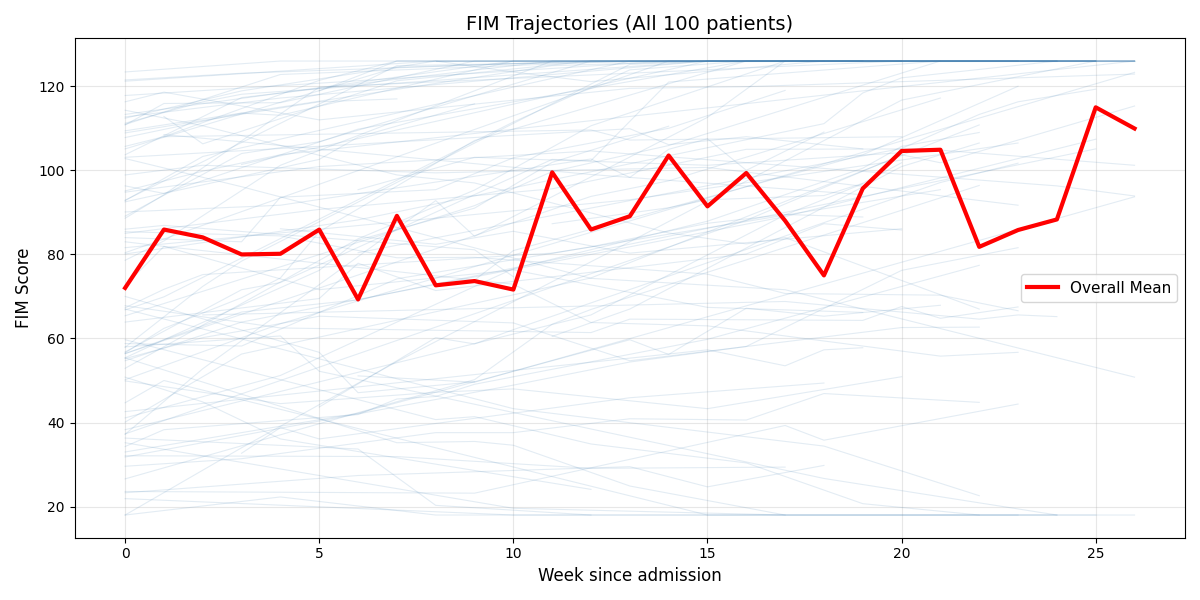

In [4]:
# ====================================================
# 全員FIM軌跡の可視化
# ====================================================
fig_all, ax_all = plt.subplots(figsize=(12, 6))

for pid, grp in data.groupby("ID"):
    grp_sorted = grp.sort_values("week")
    ax_all.plot(grp_sorted["week"].values, grp_sorted["FIM"].values,
                alpha=0.15, linewidth=0.8, color="steelblue")

# 全体平均
mean_traj = data.groupby("week")["FIM"].mean().reset_index().sort_values("week")
ax_all.plot(mean_traj["week"], mean_traj["FIM"], color="red", linewidth=3,
            label="Overall Mean", zorder=10)

ax_all.set_xlabel("Week since admission", fontsize=12)
ax_all.set_ylabel("FIM Score", fontsize=12)
ax_all.set_title(f"FIM Trajectories (All {data['ID'].nunique()} patients)", fontsize=14)
ax_all.legend(fontsize=11)
ax_all.grid(True, alpha=0.3)
fig_all.tight_layout()
plt.show()


## 4. インタラクティブダッシュボード

### フィルタ条件
- **0週FIMスコアなし除外**: 0週のFIMスコアがない患者を除外するかどうか
- **0週FIMスコア範囲**: 0週のFIMスコアの下限・上限
- **Week上限**: 分析に含めるweekの上限

### 出力
- 情報量基準（BIC）による最適クラスタ数
- Individual Trajectories (sampled) + Class Means
- クラスタ別 Table 1


In [5]:
# ====================================================
# ヘルパー関数
# ====================================================

def extract_trajectory_features(df):
    """
    患者ごとに FIM ~ week の線形回帰を行い、切片・傾き・観測数を特徴量として返す。
    LCMM の簡易近似として使用（高速）。
    """
    features = []
    for pid, grp in df.groupby("ID"):
        grp_s = grp.sort_values("week")
        weeks = grp_s["week"].values.astype(float)
        fims = grp_s["FIM"].values.astype(float)

        if len(weeks) < 2:
            features.append({
                "ID": pid,
                "intercept": fims[0],
                "slope": 0.0,
                "n_obs": len(weeks),
                "mean_fim": fims.mean(),
                "baseline_fim": fims[0]
            })
            continue

        try:
            slope, intercept = np.polyfit(weeks, fims, 1)
        except Exception:
            slope, intercept = 0.0, fims.mean()

        features.append({
            "ID": pid,
            "intercept": intercept,
            "slope": slope,
            "n_obs": len(weeks),
            "mean_fim": fims.mean(),
            "baseline_fim": fims[0]
        })

    return pd.DataFrame(features)


def find_optimal_clusters(features_scaled, max_k=6, min_k=1):
    """
    BIC で最適クラスタ数を選択する。
    Returns: best_k, bic_values dict, all fitted models dict
    """
    bic_values = {}
    models = {}

    for k in range(min_k, max_k + 1):
        gmm = GaussianMixture(
            n_components=k,
            covariance_type='full',
            n_init=10,
            max_iter=300,
            random_state=42
        )
        gmm.fit(features_scaled)
        bic_values[k] = gmm.bic(features_scaled)
        models[k] = gmm

    best_k = min(bic_values, key=bic_values.get)
    return best_k, bic_values, models


def make_table1(baseline_df, group_col="FIM_class", id_col="ID"):
    """
    TableOne を使ってクラスタ別 Table 1 を生成する。
    """
    d = baseline_df.copy()
    d[group_col] = d[group_col].astype(str)

    # 除外列
    exclude = [id_col, group_col, "week", "intercept", "slope", "n_obs",
               "mean_fim", "baseline_fim", "FIM_class_label"]

    # 分析に使う列
    cols = [c for c in d.columns if c not in exclude and d[c].notna().sum() > 0]

    if len(cols) == 0:
        return None, "分析可能な列がありません"

    # カテゴリ変数の推定
    categorical = []
    for c in cols:
        s = d[c]
        if pd.api.types.is_bool_dtype(s):
            categorical.append(c)
        elif pd.api.types.is_numeric_dtype(s):
            if s.dropna().nunique() <= 10:
                categorical.append(c)
        else:
            categorical.append(c)

    try:
        table1 = TableOne(
            d,
            columns=cols,
            categorical=categorical,
            groupby=group_col,
            pval=True,
            missing=True
        )
        return table1, None
    except Exception as e:
        return None, str(e)


# ====================================================
# リンクヘルパー: スライダ <-> IntText 双方向同期
# ====================================================
def _link_slider_text(slider, text):
    """スライダとIntTextを双方向リンクする"""
    _updating = [False]
    def _on_slider(change):
        if not _updating[0]:
            _updating[0] = True
            text.value = change['new']
            _updating[0] = False
    def _on_text(change):
        if not _updating[0]:
            _updating[0] = True
            v = change['new']
            v = max(slider.min, min(slider.max, v))
            slider.value = v
            text.value = v
            _updating[0] = False
    slider.observe(_on_slider, names='value')
    text.observe(_on_text, names='value')

def _link_range_slider_texts(slider, text_lo, text_hi):
    """IntRangeSliderと2つのIntTextを双方向リンクする"""
    _updating = [False]
    def _on_slider(change):
        if not _updating[0]:
            _updating[0] = True
            lo, hi = change['new']
            text_lo.value = lo
            text_hi.value = hi
            _updating[0] = False
    def _on_text_lo(change):
        if not _updating[0]:
            _updating[0] = True
            lo = max(slider.min, min(change['new'], slider.value[1]))
            slider.value = (lo, slider.value[1])
            text_lo.value = lo
            _updating[0] = False
    def _on_text_hi(change):
        if not _updating[0]:
            _updating[0] = True
            hi = min(slider.max, max(change['new'], slider.value[0]))
            slider.value = (slider.value[0], hi)
            text_hi.value = hi
            _updating[0] = False
    slider.observe(_on_slider, names='value')
    text_lo.observe(_on_text_lo, names='value')
    text_hi.observe(_on_text_hi, names='value')


print("Helper functions defined.")

Helper functions defined.


In [6]:
# ====================================================
# インタラクティブダッシュボード
# ====================================================

# --- 0週のFIM範囲を事前計算 ---
week0_data = data[data["week"] == 0]
week0_ids = set(week0_data["ID"].unique())
has_week0_pct = len(week0_ids) / data["ID"].nunique() * 100

if len(week0_data) > 0:
    fim_min_w0 = int(week0_data["FIM"].min())
    fim_max_w0 = int(week0_data["FIM"].max())
else:
    fim_min_w0 = int(data["FIM"].min())
    fim_max_w0 = int(data["FIM"].max())

week_max_data = int(data["week"].max())

print(f"0週FIMあり患者: {len(week0_ids)}/{data['ID'].nunique()} ({has_week0_pct:.1f}%)")
print(f"0週FIM範囲: {fim_min_w0} - {fim_max_w0}")
print(f"最大week: {week_max_data}")

# ====================================================
# ウィジェット定義（スライダ + 数値入力）
# ====================================================
style = {'description_width': '200px'}
slider_layout = widgets.Layout(width='400px')
text_layout = widgets.Layout(width='80px')

w_exclude_no_week0 = widgets.Checkbox(
    value=False,
    description='0週FIMなし症例を除外',
    style=style,
    layout=widgets.Layout(width='500px')
)

# --- 0週FIMスコア範囲 ---
w_fim_range = widgets.IntRangeSlider(
    value=[fim_min_w0, fim_max_w0],
    min=fim_min_w0,
    max=fim_max_w0,
    step=1,
    description='0週FIMスコア範囲:',
    style=style,
    layout=slider_layout,
    continuous_update=False
)
w_fim_lo_text = widgets.IntText(value=fim_min_w0, layout=text_layout, description='')
w_fim_hi_text = widgets.IntText(value=fim_max_w0, layout=text_layout, description='')
_link_range_slider_texts(w_fim_range, w_fim_lo_text, w_fim_hi_text)
w_fim_row = widgets.HBox([w_fim_range, widgets.Label('数値入力:'), w_fim_lo_text, widgets.Label('〜'), w_fim_hi_text])

# --- Week上限 ---
w_week_max = widgets.IntSlider(
    value=min(26, week_max_data),
    min=1,
    max=week_max_data,
    step=1,
    description='Week上限:',
    style=style,
    layout=slider_layout,
    continuous_update=False
)
w_week_max_text = widgets.IntText(value=w_week_max.value, layout=text_layout, description='')
_link_slider_text(w_week_max, w_week_max_text)
w_week_row = widgets.HBox([w_week_max, w_week_max_text])

# --- 最大クラスタ数 ---
w_max_k = widgets.IntSlider(
    value=6,
    min=2,
    max=10,
    step=1,
    description='最大クラスタ数:',
    style=style,
    layout=slider_layout,
    continuous_update=False
)
w_max_k_text = widgets.IntText(value=6, layout=text_layout, description='')
_link_slider_text(w_max_k, w_max_k_text)
w_max_k_row = widgets.HBox([w_max_k, w_max_k_text])

# --- 表示サンプル数 ---
w_n_sample = widgets.IntSlider(
    value=30,
    min=5,
    max=100,
    step=5,
    description='表示サンプル数/クラス:',
    style=style,
    layout=slider_layout,
    continuous_update=False
)
w_n_sample_text = widgets.IntText(value=30, layout=text_layout, description='')
_link_slider_text(w_n_sample, w_n_sample_text)
w_n_sample_row = widgets.HBox([w_n_sample, w_n_sample_text])

run_btn = widgets.Button(
    description='分析実行',
    button_style='success',
    icon='play',
    layout=widgets.Layout(width='200px', height='40px')
)

status_out = widgets.HTML(value='')

# 出力エリア
out_bic = widgets.Output()
out_traj = widgets.Output()
out_table1 = widgets.Output()

# ====================================================
# メイン分析関数
# ====================================================
def run_analysis(b=None):
    t_start = time.time()
    status_out.value = '<b style="color:blue">分析中...</b>'

    # 出力クリア
    out_bic.clear_output(wait=True)
    out_traj.clear_output(wait=True)
    out_table1.clear_output(wait=True)

    # --- フィルタ適用 ---
    df = data.copy()

    # Week上限フィルタ
    df = df[df["week"] <= w_week_max.value]

    # 0週FIMなし除外
    if w_exclude_no_week0.value:
        ids_with_w0 = set(df[df["week"] == 0]["ID"].unique())
        df = df[df["ID"].isin(ids_with_w0)]

    # 0週FIMスコア範囲フィルタ
    fim_lo, fim_hi = w_fim_range.value
    w0 = df[df["week"] == 0]
    if len(w0) > 0:
        ids_in_range = set(
            w0[(w0["FIM"] >= fim_lo) & (w0["FIM"] <= fim_hi)]["ID"].unique()
        )
        if w_exclude_no_week0.value:
            df = df[df["ID"].isin(ids_in_range)]
        else:
            ids_no_w0 = set(df["ID"].unique()) - set(w0["ID"].unique())
            df = df[df["ID"].isin(ids_in_range | ids_no_w0)]

    # 再度3点以上チェック
    id_counts = df["ID"].value_counts()
    ids_ge3 = id_counts[id_counts >= 3].index
    df = df[df["ID"].isin(ids_ge3)].copy()

    n_patients = df["ID"].nunique()
    n_obs = len(df)

    if n_patients < 3:
        status_out.value = f'<b style="color:red">フィルタ後の患者数が少なすぎます ({n_patients}人)。条件を緩和してください。</b>'
        return

    # --- 特徴量抽出 ---
    t_feat = time.time()
    feat_df = extract_trajectory_features(df)
    t_feat_done = time.time()

    # スケーリング
    scaler = StandardScaler()
    X = scaler.fit_transform(feat_df[["intercept", "slope"]].values)

    # --- 最適クラスタ数 ---
    t_clust = time.time()
    max_k = min(w_max_k.value, n_patients - 1)
    max_k = max(max_k, 2)
    best_k, bic_values, gmm_models = find_optimal_clusters(X, max_k=max_k)
    t_clust_done = time.time()

    # クラスラベル付与
    best_model = gmm_models[best_k]
    feat_df["cluster"] = best_model.predict(X)

    # クラスを平均FIMの昇順でソート（直感的に）
    cluster_means = feat_df.groupby("cluster")["mean_fim"].mean().sort_values()
    cluster_map = {old: new for new, old in enumerate(cluster_means.index)}
    feat_df["FIM_class"] = feat_df["cluster"].map(cluster_map)

    # データにクラスラベルを付与
    df = df.merge(feat_df[["ID", "FIM_class"]], on="ID", how="left")

    # --- BIC プロット ---
    with out_bic:
        clear_output(wait=True)
        fig_bic, ax_bic = plt.subplots(figsize=(8, 4))
        ks = sorted(bic_values.keys())
        bics = [bic_values[k] for k in ks]

        ax_bic.plot(ks, bics, 'o-', color='green', markersize=10, linewidth=2)
        ax_bic.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
                       label=f'Best: {best_k} classes (BIC={bic_values[best_k]:.1f})')
        ax_bic.scatter([best_k], [bic_values[best_k]], color='red', s=200, marker='*', zorder=10)
        ax_bic.set_xlabel("Number of Classes", fontsize=12)
        ax_bic.set_ylabel("BIC", fontsize=12)
        ax_bic.set_title("BIC by Number of Classes (lower = better)", fontsize=13)
        ax_bic.set_xticks(ks)
        ax_bic.legend(fontsize=11)
        ax_bic.grid(True, alpha=0.3)
        fig_bic.tight_layout()
        plt.show()

        # クラス分布表示
        class_counts = feat_df["FIM_class"].value_counts().sort_index()
        print(f"\n最適クラスタ数: {best_k} (BIC = {bic_values[best_k]:.1f})")
        print(f"患者数: {n_patients}, 観測数: {n_obs}")
        print(f"\nクラス分布:")
        for cls in sorted(class_counts.index):
            n = class_counts[cls]
            pct = n / n_patients * 100
            print(f"  Class {cls}: {n} patients ({pct:.1f}%)")

    # --- Trajectory プロット ---
    with out_traj:
        clear_output(wait=True)

        fig_traj, ax_traj = plt.subplots(figsize=(12, 7))

        # カラーマップ
        n_classes = best_k
        cmap = plt.cm.get_cmap('tab10', n_classes)
        colors = [cmap(i) for i in range(n_classes)]

        # クラス平均
        mean_traj = (
            df.dropna(subset=["FIM_class"])
            .groupby(["FIM_class", "week"], as_index=False)["FIM"]
            .mean()
            .sort_values(["FIM_class", "week"])
        )

        # サンプル個人軌跡
        np.random.seed(42)
        n_sample = w_n_sample.value

        for cls in sorted(df["FIM_class"].dropna().unique()):
            cls_int = int(cls)
            color = colors[cls_int % len(colors)]

            # サンプリング
            cls_ids = df[df["FIM_class"] == cls]["ID"].unique()
            sample_size = min(n_sample, len(cls_ids))
            sampled = np.random.choice(cls_ids, size=sample_size, replace=False)

            # 個人軌跡（薄く）
            for pid in sampled:
                pdata = df[df["ID"] == pid].sort_values("week")
                ax_traj.plot(pdata["week"].values, pdata["FIM"].values,
                            alpha=0.12, linewidth=0.8, color=color)

            # クラス平均（太く）
            cls_mean = mean_traj[mean_traj["FIM_class"] == cls]
            ax_traj.plot(cls_mean["week"], cls_mean["FIM"],
                        marker='o', linewidth=4, color=color,
                        label=f'Class {cls_int} (n={len(cls_ids)})',
                        zorder=10, markersize=6)

        ax_traj.set_xlabel("Week since admission", fontsize=12)
        ax_traj.set_ylabel("FIM Score", fontsize=12)
        ax_traj.set_title(
            f"Individual Trajectories (sampled, {n_sample}/class) + Class Means\n"
            f"({best_k} classes, {n_patients} patients, week <= {w_week_max.value})",
            fontsize=13
        )
        ax_traj.legend(fontsize=11, loc='best')
        ax_traj.grid(True, alpha=0.3)
        fig_traj.tight_layout()
        plt.show()

    # --- Table 1 ---
    with out_table1:
        clear_output(wait=True)

        # ベースラインデータ作成（week==0優先、なければ最小week）
        baseline_parts = []

        # week==0 がある患者
        d0 = df[df["week"] == 0].copy()
        if len(d0) > 0:
            d0_base = d0.sort_values(["ID", "week"]).drop_duplicates(subset=["ID"], keep="first")
            baseline_parts.append(d0_base)
            ids_with_w0 = set(d0_base["ID"].unique())
        else:
            ids_with_w0 = set()

        # week==0 がない患者 → 最小weekを使用
        df_no_w0 = df[~df["ID"].isin(ids_with_w0)]
        if len(df_no_w0) > 0:
            d_min = df_no_w0.sort_values(["ID", "week"]).drop_duplicates(subset=["ID"], keep="first")
            baseline_parts.append(d_min)

        if baseline_parts:
            baseline = pd.concat(baseline_parts, axis=0).reset_index(drop=True)
        else:
            baseline = df.sort_values(["ID", "week"]).drop_duplicates(subset=["ID"], keep="first").reset_index(drop=True)

        # FIM_class ラベル
        baseline["FIM_class_label"] = baseline["FIM_class"].apply(
            lambda x: f"Class {int(x)}" if pd.notna(x) else "NA"
        )
        baseline = baseline.dropna(subset=["FIM_class"])

        print(f"=== Table 1 ({best_k} classes, {len(baseline)} patients) ===\n")

        table1_obj, err = make_table1(baseline, group_col="FIM_class_label", id_col="ID")

        if table1_obj is not None:
            print(table1_obj.tabulate(tablefmt="grid"))
        else:
            print(f"Table 1 生成エラー: {err}")

    t_end = time.time()
    status_out.value = (
        f'<b style="color:green">完了!</b> '
        f'({n_patients}人, {n_obs}obs, {best_k}クラス) '
        f'| 特徴量抽出: {(t_feat_done-t_feat)*1000:.0f}ms '
        f'| クラスタリング: {(t_clust_done-t_clust)*1000:.0f}ms '
        f'| 合計: {(t_end-t_start):.2f}s'
    )

run_btn.on_click(run_analysis)

# ====================================================
# レイアウト
# ====================================================
controls = widgets.VBox([
    widgets.HTML(value='<h3>フィルタ設定</h3>'),
    w_exclude_no_week0,
    w_fim_row,
    w_week_row,
    widgets.HTML(value='<h3>分析設定</h3>'),
    w_max_k_row,
    w_n_sample_row,
    run_btn,
    status_out
], layout=widgets.Layout(padding='10px', border='1px solid #ccc', width='650px'))

outputs = widgets.VBox([
    widgets.HTML(value='<h3>BIC によるクラスタ数選択</h3>'),
    out_bic,
    widgets.HTML(value='<h3>Individual Trajectories + Class Means</h3>'),
    out_traj,
    widgets.HTML(value='<h3>Table 1 (クラスタ別ベースライン特性)</h3>'),
    out_table1
], layout=widgets.Layout(padding='10px', width='100%'))

dashboard = widgets.VBox([
    widgets.HTML(value='<h2>FIM軌跡 インタラクティブダッシュボード</h2>'),
    widgets.HBox([controls, outputs])
])

display(dashboard)
print("\n分析実行ボタンを押してダッシュボードを更新してください。")

0週FIMあり患者: 83/100 (83.0%)
0週FIM範囲: 18 - 123
最大week: 26



分析実行ボタンを押してダッシュボードを更新してください。


## 5. リアクティブモード（オプション）

下のセルを実行すると、ウィジェットの値が変更されるたびに自動で分析が再実行されます。  
（初回は上の「分析実行」ボタンで手動実行してください）


In [7]:
# ====================================================
# リアクティブモード: ウィジェット変更時に自動再実行
# ====================================================
# debounce用のタイマー
_last_change_time = [0.0]
_debounce_ms = 500  # 500ms debounce

def _on_widget_change(change):
    import threading
    _last_change_time[0] = time.time()
    t = _last_change_time[0]

    def _delayed_run():
        time.sleep(_debounce_ms / 1000.0)
        if _last_change_time[0] == t:
            run_analysis()

    thread = threading.Thread(target=_delayed_run, daemon=True)
    thread.start()

# ウィジェットにオブザーバーを登録
for w in [w_exclude_no_week0, w_fim_range, w_week_max, w_max_k, w_n_sample]:
    w.observe(_on_widget_change, names='value')

print("リアクティブモード有効: ウィジェット変更で自動再分析されます (debounce: 500ms)")


リアクティブモード有効: ウィジェット変更で自動再分析されます (debounce: 500ms)


## 6. LCMMモード（Latent Class Mixed Model）

上記のGMMモードでは、患者ごとの軌跡特徴量（切片・傾き）を抽出してクラスタリングしていました。  
ここでは **R の `lcmm` パッケージ（`hlme` 関数）** を使い、縦断データを直接モデリングする本来のLCMMを実行します。

### 違い
| | GMMモード | LCMMモード |
|---|---|---|
| 手法 | 特徴量抽出 → GMM | 縦断データ → hlme |
| ランダム効果 | なし | あり（random intercept） |
| 時系列相関 | 考慮しない | モデル内で考慮 |
| 速度 | 数秒 | 数十秒〜数分 |
| パッケージ | scikit-learn | R/lcmm via rpy2 |

### 注意
- **R と rpy2 が必要です**: `pip install rpy2` および R に `lcmm` パッケージをインストールしてください
- 実行時間はデータサイズとクラスタ数に依存します（数十秒〜数分）
- リアクティブモードは設けていません（手動の「LCMM分析実行」ボタンで実行）


In [8]:
# ====================================================
# LCMM モード: インポートとセットアップ
# ====================================================
import math
import threading

try:
    import rpy2.robjects as ro
    from rpy2.robjects import pandas2ri
    from rpy2.robjects.conversion import localconverter
    from rpy2.robjects.packages import importr

    # pandas <-> R 変換用コンバータ
    _pandas_converter = ro.default_converter + pandas2ri.converter

    # lcmm パッケージのロード
    lcmm_r = importr('lcmm')
    base_r = importr('base')

    r_version = ro.r('R.version.string')[0]
    lcmm_version = str(ro.r('packageVersion("lcmm")')[0])
    print(f"R: {r_version}")
    print(f"lcmm: {lcmm_version}")
    print("LCMM モード利用可能")
    _LCMM_AVAILABLE = True
except Exception as e:
    print(f"LCMM モード利用不可: {e}")
    print("rpy2 と R/lcmm をインストールしてください:")
    print("  pip install rpy2")
    print('  R -e \'install.packages("lcmm", repos="https://cloud.r-project.org")\'')
    _LCMM_AVAILABLE = False


R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1:   
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  library ‘/usr/lib/R/site-library’ contains no packages
  
R callback write-console: 2:   
R callback write-console: In (function (package, help, pos = 2, lib.loc = NULL, character.only = FALSE,  :  
R callback write-console: 
   
R callback write-console:  library ‘/usr/lib/R/site-library’ contains no packages
  


R: R version 4.1.2 (2021-11-01)
lcmm: [1] 2 2 2

LCMM モード利用可能


In [9]:
# ====================================================
# LCMM ヘルパー関数
# ====================================================
import tempfile as _tempfile

def _py2rpy_to_globalenv(df, varname):
    """pandas DataFrame を R globalenv に直接代入 (widget callback対応)
    rpy2 の converter は contextvars に依存するため widget callback で失敗する。
    CSV 経由で安全に変換し、R 側で assign() する。
    """
    with _tempfile.NamedTemporaryFile(suffix='.csv', delete=False, mode='w') as f:
        df.to_csv(f, index=False)
        tmp_path = f.name
    tmp_path_r = tmp_path.replace("\\", "/")
    ro.r(f'{varname} <- read.csv("{tmp_path_r}", stringsAsFactors=FALSE)')
    import os
    os.unlink(tmp_path)

def _rpy2py_globalenv(varname):
    """R globalenv の変数名から pandas DataFrame に変換"""
    with _tempfile.NamedTemporaryFile(suffix='.csv', delete=False, mode='w') as f:
        tmp_path = f.name
    tmp_path_r = tmp_path.replace("\\", "/")
    ro.r(f'write.csv(as.data.frame({varname}), "{tmp_path_r}", row.names=FALSE)')
    result = pd.read_csv(tmp_path)
    import os
    os.unlink(tmp_path)
    return result

def _r_scalar(expr):
    """R のスカラー値を Python float/int で取得 (converter不要)"""
    return float(ro.r(expr)[0])

def prepare_data_for_lcmm(df_filtered):
    """フィルタ済みデータを R の lcmm 用に準備する"""
    d = df_filtered[["ID", "week", "FIM"]].copy()
    d["ID"] = d["ID"].astype(str)
    d["week"] = pd.to_numeric(d["week"], errors="coerce")
    d["FIM"] = pd.to_numeric(d["FIM"], errors="coerce")
    d = d.dropna(subset=["ID", "week", "FIM"]).copy()

    # R に転送 (CSV経由 - widget callback対応)
    _py2rpy_to_globalenv(d, "lcmm_data_py")

    # R 側でデータ準備
    ro.r("""
    d <- lcmm_data_py
    d$week <- as.numeric(d$week)
    d$FIM  <- as.numeric(d$FIM)
    d$ID_chr <- as.character(d$ID)
    d$ID_num <- as.numeric(factor(d$ID_chr))

    # week 中心化（収束改善）
    d$week_c <- d$week - mean(d$week, na.rm=TRUE)

    # (ID, week) 重複除去
    dup_n <- sum(duplicated(d[, c("ID_chr","week")]))
    if(dup_n > 0){
      d <- aggregate(FIM ~ ID_chr + ID_num + week + week_c, data=d, FUN=mean)
    }

    d <- d[order(d$ID_num, d$week), ]
    lcmm_data <- d
    """)

    n_id = int(_r_scalar("length(unique(lcmm_data$ID_num))"))
    n_row = int(_r_scalar("nrow(lcmm_data)"))
    return n_id, n_row

def fit_lcmm_models(max_k=4, maxiter=500):
    """1 ~ max_k クラスの hlme モデルをフィット"""
    results = {}

    # --- 1クラスモデル（ベースライン） ---
    print("  hlme: 1-class ...", end="", flush=True)
    t0 = time.time()
    ro.r(f"""
    lcmm_model_1 <- hlme(
      fixed   = FIM ~ week_c,
      random  = ~ 1,
      subject = "ID_num",
      data    = lcmm_data,
      ng      = 1,
      idiag   = TRUE,
      maxiter = {maxiter},
      nproc   = 1
    )
    """)
    dt = time.time() - t0
    fit1 = _extract_lcmm_fit("lcmm_model_1")
    results[1] = fit1
    print(f" {dt:.1f}s | BIC={fit1['BIC']:.1f}", flush=True)

    # B_init を 1クラスモデルから構築
    ro.r("""
    b1 <- lcmm_model_1$best
    """)

    # --- 2+ クラスモデル ---
    for ng in range(2, max_k + 1):
        print(f"  hlme: {ng}-class ...", end="", flush=True)
        t0 = time.time()

        ro.r(f"""
        ng_val <- {ng}
        d_spread <- 5 * (ng_val - 1)
        offsets <- seq(-d_spread, d_spread, length.out=ng_val)
        pi_init <- rep(0, ng_val - 1)
        int_init <- b1[1] + offsets
        B_init_ng <- c(pi_init, int_init, b1[-1])
        """)

        try:
            ro.r(f"""
            lcmm_model_{ng} <- hlme(
              fixed   = FIM ~ week_c,
              random  = ~ 1,
              mixture = ~ 1,
              subject = "ID_num",
              data    = lcmm_data,
              ng      = {ng},
              idiag   = TRUE,
              B       = B_init_ng,
              maxiter = {maxiter},
              nproc   = 1
            )
            """)
            dt = time.time() - t0
            fit = _extract_lcmm_fit(f"lcmm_model_{ng}")
            results[ng] = fit
            print(f" {dt:.1f}s | BIC={fit['BIC']:.1f} conv={fit['conv']}", flush=True)
        except Exception as e:
            dt = time.time() - t0
            print(f" {dt:.1f}s | FAILED: {e}", flush=True)
            results[ng] = {"BIC": float("inf"), "AIC": float("inf"),
                          "loglik": float("-inf"), "conv": -1,
                          "n_params": 0, "is_valid": False}

    return results

def _extract_lcmm_fit(model_name):
    """R の lcmm モデルオブジェクトから適合度指標を抽出"""
    loglik = _r_scalar(f"{model_name}$loglik")
    aic = _r_scalar(f"{model_name}$AIC")
    bic = _r_scalar(f"{model_name}$BIC")

    try:
        conv = int(_r_scalar(f"{model_name}$conv"))
    except Exception:
        conv = -1

    is_valid = (
        math.isfinite(loglik) and math.isfinite(aic) and math.isfinite(bic)
        and abs(aic) < 1e8 and abs(bic) < 1e8
    )

    n_params = int(round((aic + 2 * loglik) / 2)) if is_valid else 0

    return {
        "loglik": loglik,
        "AIC": aic,
        "BIC": bic,
        "n_params": n_params,
        "conv": conv,
        "is_valid": is_valid
    }

def get_lcmm_class_assignments(model_name, ng):
    """lcmm モデルから事後クラス割り当てを取得"""
    ro.r(f"""
    pprob <- {model_name}$pprob
    """)
    pprob_df = _rpy2py_globalenv("pprob")

    id_num = pprob_df["ID_num" if "ID_num" in pprob_df.columns else pprob_df.columns[0]]
    class_col = "class" if "class" in pprob_df.columns else pprob_df.columns[1]
    class_assignments = pprob_df[class_col].astype(int)

    id_map = _rpy2py_globalenv('data.frame(ID_num=lcmm_data$ID_num, ID_chr=lcmm_data$ID_chr)')
    id_map = id_map.drop_duplicates(subset=["ID_num"])

    result = pd.DataFrame({
        "ID_num": id_num.values,
        "lcmm_class_raw": class_assignments.values
    })
    result = result.merge(id_map, on="ID_num", how="left")
    result = result.rename(columns={"ID_chr": "ID"})

    result["ID"] = result["ID"].astype(str)
    return result[["ID", "lcmm_class_raw"]]

def get_lcmm_predicted_trajectories(model_name, ng):
    """lcmm モデルからクラス別予測軌跡を取得"""
    ro.r(f"""
    week_range <- range(lcmm_data$week)
    week_mean <- mean(lcmm_data$week, na.rm=TRUE)
    pred_weeks <- seq(week_range[1], week_range[2], length.out=50)
    pred_data <- data.frame(week_c = pred_weeks - week_mean)

    pred_result <- predictY({model_name}, newdata=pred_data, var.time="week_c")
    pred_df <- as.data.frame(pred_result$pred)
    pred_df$week <- pred_weeks
    """)
    pred_df = _rpy2py_globalenv("pred_df")
    return pred_df

if _LCMM_AVAILABLE:

    # widget callback は別スレッドで実行されるため
    # rpy2 の converter context を伝搬する必要がある
    import contextvars as _contextvars
    _main_thread_ctx = _contextvars.copy_context()

    def _run_in_main_ctx(func):
        """widget callback を main thread の context で実行するデコレータ"""
        def wrapper(*args, **kwargs):
            return _main_thread_ctx.run(func, *args, **kwargs)
        return wrapper

    print("LCMM ヘルパー関数定義完了")

LCMM ヘルパー関数定義完了


In [10]:
# ====================================================
# LCMM ダッシュボード（手動実行ボタンのみ）
# ====================================================
if not _LCMM_AVAILABLE:
    print("LCMM モードは利用できません。rpy2 と R/lcmm をインストールしてください。")
else:
    # --- ウィジェット定義（データの実際の値を使用） ---
    _lcmm_style = {'description_width': 'auto'}
    _lcmm_slider_layout = widgets.Layout(width='350px')
    _lcmm_text_layout = widgets.Layout(width='80px')

    lcmm_w_exclude_no_week0 = widgets.Checkbox(
        value=False,
        description='0週FIMなし症例を除外',
        style=_lcmm_style,
        layout=widgets.Layout(width='400px')
    )

    # --- 0週FIMスコア範囲（データの実際の値を使用） ---
    lcmm_w_fim_range = widgets.IntRangeSlider(
        value=[fim_min_w0, fim_max_w0],
        min=fim_min_w0, max=fim_max_w0, step=1,
        description='0週FIMスコア範囲:',
        style=_lcmm_style,
        layout=_lcmm_slider_layout,
        continuous_update=False
    )
    lcmm_w_fim_lo_text = widgets.IntText(value=fim_min_w0, layout=_lcmm_text_layout)
    lcmm_w_fim_hi_text = widgets.IntText(value=fim_max_w0, layout=_lcmm_text_layout)
    _link_range_slider_texts(lcmm_w_fim_range, lcmm_w_fim_lo_text, lcmm_w_fim_hi_text)
    lcmm_w_fim_row = widgets.HBox([lcmm_w_fim_range, widgets.Label('数値入力:'), lcmm_w_fim_lo_text, widgets.Label('〜'), lcmm_w_fim_hi_text])

    # --- Week上限（データの実際の最大値を使用） ---
    lcmm_w_week_max = widgets.IntSlider(
        value=min(26, week_max_data), min=1, max=week_max_data, step=1,
        description='Week上限:',
        style=_lcmm_style,
        layout=_lcmm_slider_layout,
        continuous_update=False
    )
    lcmm_w_week_max_text = widgets.IntText(value=lcmm_w_week_max.value, layout=_lcmm_text_layout)
    _link_slider_text(lcmm_w_week_max, lcmm_w_week_max_text)
    lcmm_w_week_row = widgets.HBox([lcmm_w_week_max, lcmm_w_week_max_text])

    # --- 最大クラスタ数 ---
    lcmm_w_max_k = widgets.IntSlider(
        value=4, min=2, max=6, step=1,
        description='最大クラスタ数:',
        style=_lcmm_style,
        layout=_lcmm_slider_layout,
        continuous_update=False
    )
    lcmm_w_max_k_text = widgets.IntText(value=4, layout=_lcmm_text_layout)
    _link_slider_text(lcmm_w_max_k, lcmm_w_max_k_text)
    lcmm_w_max_k_row = widgets.HBox([lcmm_w_max_k, lcmm_w_max_k_text])

    # --- 表示サンプル数 ---
    lcmm_w_n_sample = widgets.IntSlider(
        value=30, min=5, max=100, step=5,
        description='表示サンプル数/クラス:',
        style=_lcmm_style,
        layout=_lcmm_slider_layout,
        continuous_update=False
    )
    lcmm_w_n_sample_text = widgets.IntText(value=30, layout=_lcmm_text_layout)
    _link_slider_text(lcmm_w_n_sample, lcmm_w_n_sample_text)
    lcmm_w_n_sample_row = widgets.HBox([lcmm_w_n_sample, lcmm_w_n_sample_text])

    # --- 最大反復回数 ---
    lcmm_w_maxiter = widgets.IntSlider(
        value=500, min=100, max=2000, step=100,
        description='最大反復回数:',
        style=_lcmm_style,
        layout=_lcmm_slider_layout,
        continuous_update=False
    )
    lcmm_w_maxiter_text = widgets.IntText(value=500, layout=_lcmm_text_layout)
    _link_slider_text(lcmm_w_maxiter, lcmm_w_maxiter_text)
    lcmm_w_maxiter_row = widgets.HBox([lcmm_w_maxiter, lcmm_w_maxiter_text])

    lcmm_run_btn = widgets.Button(
        description='LCMM 分析実行',
        button_style='warning',
        icon='play',
        layout=widgets.Layout(width='220px', height='45px')
    )

    lcmm_status_out = widgets.HTML(value='')

    lcmm_out_bic = widgets.Output()
    lcmm_out_traj = widgets.Output()
    lcmm_out_table1 = widgets.Output()

    # ====================================================
    # LCMM メイン分析関数
    # ====================================================
    @_run_in_main_ctx
    def run_lcmm_analysis(b=None):
        t_start = time.time()
        lcmm_status_out.value = '<b style="color:orange">LCMM 分析中... (数十秒〜数分かかります)</b>'

        lcmm_out_bic.clear_output(wait=True)
        lcmm_out_traj.clear_output(wait=True)
        lcmm_out_table1.clear_output(wait=True)

        try:
            # --- フィルタ適用（GMMモードと同じロジック） ---
            df = data.copy()
            df = df[df["week"] <= lcmm_w_week_max.value]

            if lcmm_w_exclude_no_week0.value:
                ids_with_w0 = set(df[df["week"] == 0]["ID"].unique())
                df = df[df["ID"].isin(ids_with_w0)]

            fim_lo, fim_hi = lcmm_w_fim_range.value
            w0 = df[df["week"] == 0]
            if len(w0) > 0:
                ids_in_range = set(
                    w0[(w0["FIM"] >= fim_lo) & (w0["FIM"] <= fim_hi)]["ID"].unique()
                )
                if lcmm_w_exclude_no_week0.value:
                    df = df[df["ID"].isin(ids_in_range)]
                else:
                    ids_no_w0 = set(df["ID"].unique()) - set(w0["ID"].unique())
                    df = df[df["ID"].isin(ids_in_range | ids_no_w0)]

            id_counts = df["ID"].value_counts()
            ids_ge3 = id_counts[id_counts >= 3].index
            df = df[df["ID"].isin(ids_ge3)].copy()

            n_patients = df["ID"].nunique()
            n_obs = len(df)

            if n_patients < 5:
                lcmm_status_out.value = (
                    '<b style="color:red">'
                    + 'フィルタ後の患者数が少なすぎます ('
                    + str(n_patients)
                    + '人)。条件を緩和してください。'
                    + '</b>'
                )
                return

            lcmm_status_out.value = (
                '<b style="color:orange">'
                + 'データ準備中... ('
                + str(n_patients) + '人, ' + str(n_obs) + 'obs)'
                + '</b>'
            )

            n_id, n_row = prepare_data_for_lcmm(df)

            max_k = min(lcmm_w_max_k.value, n_patients // 3)
            max_k = max(max_k, 2)
            lcmm_status_out.value = (
                '<b style="color:orange">'
                + 'hlme フィッティング中... (1〜'
                + str(max_k) + 'クラス, ' + str(n_id) + '人)'
                + '</b>'
            )

            with lcmm_out_bic:
                clear_output(wait=True)
                print("hlme フィッティング中...")
                fit_results = fit_lcmm_models(max_k=max_k, maxiter=lcmm_w_maxiter.value)

            t_fit_done = time.time()

            valid_fits = {k: v for k, v in fit_results.items() if v["is_valid"]}
            if not valid_fits:
                lcmm_status_out.value = (
                    '<b style="color:red">'
                    + '有効なモデルがありません。maxiter を増やすか条件を変更してください。'
                    + '</b>'
                )
                return

            best_k = min(valid_fits, key=lambda k: valid_fits[k]["BIC"])
            best_model_name = "lcmm_model_" + str(best_k)

            class_df = get_lcmm_class_assignments(best_model_name, best_k)

            class_df["ID"] = class_df["ID"].astype(str)
            df_with_class = df.merge(class_df, on="ID", how="inner")
            class_means = df_with_class.groupby("lcmm_class_raw")["FIM"].mean().sort_values()
            class_map = {old: new for new, old in enumerate(class_means.index)}
            df_with_class["FIM_class"] = df_with_class["lcmm_class_raw"].map(class_map)

            # --- BIC プロット ---
            with lcmm_out_bic:
                clear_output(wait=True)
                fig_bic, ax_bic = plt.subplots(figsize=(8, 4))
                ks = sorted(fit_results.keys())
                bics = [fit_results[k]["BIC"] for k in ks]
                colors_bic = ['green' if fit_results[k]["is_valid"] else 'gray' for k in ks]

                ax_bic.plot(ks, bics, 'o-', color='green', markersize=10, linewidth=2)
                for k_i, bic_i, c_i in zip(ks, bics, colors_bic):
                    ax_bic.scatter([k_i], [bic_i], color=c_i, s=80, zorder=5)

                best_bic_val = fit_results[best_k]["BIC"]
                ax_bic.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
                               label='Best: ' + str(best_k) + ' classes (BIC=' + format(best_bic_val, '.1f') + ')')
                ax_bic.scatter([best_k], [best_bic_val], color='red', s=200, marker='*', zorder=10)
                ax_bic.set_xlabel("Number of Classes", fontsize=12)
                ax_bic.set_ylabel("BIC", fontsize=12)
                ax_bic.set_title("LCMM: BIC by Number of Classes (lower = better)", fontsize=13)
                ax_bic.set_xticks(ks)
                ax_bic.legend(fontsize=11)
                ax_bic.grid(True, alpha=0.3)
                fig_bic.tight_layout()
                plt.show()

                print("")
                print("=" * 60)
                print("{:>4} | {:>10} | {:>10} | {:>10} | {:>4} | {:>4} | {:>5}".format(
                    "ng", "logLik", "AIC", "BIC", "k", "conv", "valid"))
                print("-" * 60)
                for k in ks:
                    f = fit_results[k]
                    print("{:>4} | {:>10.1f} | {:>10.1f} | {:>10.1f} | {:>4} | {:>4} | {:>5}".format(
                        k, f['loglik'], f['AIC'], f['BIC'], f['n_params'], f['conv'], str(f['is_valid'])))
                print("=" * 60)
                print("\n最適クラスタ数（BIC最小）: " + str(best_k))

                class_counts = df_with_class.groupby("FIM_class")["ID"].nunique().sort_index()
                print("\nクラス分布:")
                for cls in sorted(class_counts.index):
                    n = class_counts[cls]
                    pct = n / n_patients * 100
                    print("  Class {}: {} patients ({:.1f}%)".format(cls, n, pct))

            # --- Trajectory プロット ---
            with lcmm_out_traj:
                clear_output(wait=True)
                fig_traj, ax_traj = plt.subplots(figsize=(12, 7))
                n_classes = best_k
                cmap = plt.cm.get_cmap('tab10', n_classes)
                colors = [cmap(i) for i in range(n_classes)]

                np.random.seed(42)
                n_sample = lcmm_w_n_sample.value

                for cls in sorted(df_with_class["FIM_class"].dropna().unique()):
                    cls_int = int(cls)
                    color = colors[cls_int % len(colors)]

                    cls_ids = df_with_class[df_with_class["FIM_class"] == cls]["ID"].unique()
                    sample_size = min(n_sample, len(cls_ids))
                    sampled = np.random.choice(cls_ids, size=sample_size, replace=False)

                    for pid in sampled:
                        pdata = df_with_class[df_with_class["ID"] == pid].sort_values("week")
                        ax_traj.plot(pdata["week"].values, pdata["FIM"].values,
                                    alpha=0.12, linewidth=0.8, color=color)

                    cls_mean = (
                        df_with_class[df_with_class["FIM_class"] == cls]
                        .groupby("week", as_index=False)["FIM"].mean()
                        .sort_values("week")
                    )
                    ax_traj.plot(cls_mean["week"], cls_mean["FIM"],
                                marker='o', linewidth=4, color=color,
                                label='Class ' + str(cls_int) + ' (n=' + str(len(cls_ids)) + ')',
                                zorder=10, markersize=6)

                try:
                    pred_df = get_lcmm_predicted_trajectories(best_model_name, best_k)
                    pred_cols = [c for c in pred_df.columns if c.startswith("Ypred")]
                    if pred_cols:
                        for new_cls, old_cls in enumerate(class_means.index):
                            col_idx = old_cls - 1
                            if col_idx < len(pred_cols):
                                col = pred_cols[col_idx]
                                color = colors[new_cls % len(colors)]
                                ax_traj.plot(pred_df["week"], pred_df[col],
                                            linestyle='--', linewidth=2, color=color,
                                            alpha=0.8, zorder=9)
                except Exception as e:
                    print("予測軌跡の描画をスキップ: " + str(e))

                week_max_val = lcmm_w_week_max.value
                ax_traj.set_xlabel("Week since admission", fontsize=12)
                ax_traj.set_ylabel("FIM Score", fontsize=12)
                ax_traj.set_title(
                    "LCMM: Individual Trajectories (sampled, " + str(n_sample) + "/class) + Class Means\n"
                    + "(" + str(best_k) + " classes, " + str(n_patients) + " patients, week <= " + str(week_max_val) + ")\n"
                    + "実線=実データ平均, 破線=LCMM予測",
                    fontsize=13
                )
                ax_traj.legend(fontsize=11, loc='best')
                ax_traj.grid(True, alpha=0.3)
                fig_traj.tight_layout()
                plt.show()

            # --- Table 1 ---
            with lcmm_out_table1:
                clear_output(wait=True)

                baseline_parts = []
                d0 = df_with_class[df_with_class["week"] == 0].copy()
                if len(d0) > 0:
                    d0_base = d0.sort_values(["ID", "week"]).drop_duplicates(subset=["ID"], keep="first")
                    baseline_parts.append(d0_base)
                    ids_with_w0 = set(d0_base["ID"].unique())
                else:
                    ids_with_w0 = set()

                df_no_w0 = df_with_class[~df_with_class["ID"].isin(ids_with_w0)]
                if len(df_no_w0) > 0:
                    d_min = df_no_w0.sort_values(["ID", "week"]).drop_duplicates(subset=["ID"], keep="first")
                    baseline_parts.append(d_min)

                if baseline_parts:
                    baseline = pd.concat(baseline_parts, axis=0).reset_index(drop=True)
                else:
                    baseline = df_with_class.sort_values(["ID", "week"]).drop_duplicates(
                        subset=["ID"], keep="first").reset_index(drop=True)

                baseline["FIM_class_label"] = baseline["FIM_class"].apply(
                    lambda x: "Class " + str(int(x)) if pd.notna(x) else "NA"
                )
                baseline = baseline.dropna(subset=["FIM_class"])

                print("=== LCMM Table 1 (" + str(best_k) + " classes, " + str(len(baseline)) + " patients) ===\n")

                table1_obj, err = make_table1(baseline, group_col="FIM_class_label", id_col="ID")

                if table1_obj is not None:
                    print(table1_obj.tabulate(tablefmt="grid"))
                else:
                    print("Table 1 生成エラー: " + str(err))

            t_end = time.time()
            lcmm_status_out.value = (
                '<b style="color:green">LCMM 完了!</b> '
                + '(' + str(n_patients) + '人, ' + str(n_obs) + 'obs, ' + str(best_k) + 'クラス) '
                + '| フィッティング: ' + format(t_fit_done - t_start, '.1f') + 's '
                + '| 合計: ' + format(t_end - t_start, '.1f') + 's'
            )

        except Exception as e:
            import traceback
            lcmm_status_out.value = (
                '<b style="color:red">LCMM エラー: ' + str(e) + '</b>'
            )
            with lcmm_out_bic:
                clear_output(wait=True)
                print("エラーの詳細:")
                traceback.print_exc()

    lcmm_run_btn.on_click(run_lcmm_analysis)

    # ====================================================
    # LCMM レイアウト
    # ====================================================
    lcmm_controls = widgets.VBox([
        widgets.HTML(value='<h3>フィルタ設定（LCMM）</h3>'),
        lcmm_w_exclude_no_week0,
        lcmm_w_fim_row,
        lcmm_w_week_row,
        widgets.HTML(value='<h3>LCMM 設定</h3>'),
        lcmm_w_max_k_row,
        lcmm_w_n_sample_row,
        lcmm_w_maxiter_row,
        lcmm_run_btn,
        lcmm_status_out
    ], layout=widgets.Layout(padding='10px', border='1px solid #e67e22', width='650px'))

    lcmm_outputs = widgets.VBox([
        widgets.HTML(value='<h3>LCMM: BIC によるクラスタ数選択</h3>'),
        lcmm_out_bic,
        widgets.HTML(value='<h3>LCMM: Individual Trajectories + Class Means</h3>'),
        lcmm_out_traj,
        widgets.HTML(value='<h3>LCMM: Table 1 (クラスタ別ベースライン特性)</h3>'),
        lcmm_out_table1
    ], layout=widgets.Layout(padding='10px', width='100%'))

    lcmm_dashboard = widgets.VBox([
        widgets.HTML(value='<h2>LCMM モード（Latent Class Mixed Model）</h2>'),
        widgets.HTML(value='<p style="color:#e67e22"><b>注意:</b> 実行には数十秒〜数分かかります。</p>'),
        widgets.HBox([lcmm_controls, lcmm_outputs])
    ])

    display(lcmm_dashboard)
    print("\nLCMM分析実行ボタンを押してダッシュボードを更新してください。")


LCMM分析実行ボタンを押してダッシュボードを更新してください。
